# Fine tuning pretrained GatorTron-base to predict reasons for Cannabis Use in Lupus Patients EHR

Use Optuna to optimize hyperparameters
GatorTron-base model card: https://huggingface.co/UFNLP/gatortron-base


*Yiyu Wang 2025/10*

In [1]:
import transformers
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
import torch
from torch.optim import AdamW
import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
from textwrap import wrap
import math
from sklearn.model_selection import StratifiedKFold
from typing import Dict, List
from sklearn.metrics import roc_auc_score

from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from tqdm import tqdm
import os

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]

sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))

rcParams['figure.figsize'] = 12, 8

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device


2026-01-23 13:30:58.551707: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-23 13:30:58.573914: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-23 13:30:58.976985: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


device(type='cuda', index=0)

In [2]:
df_test = pd.read_csv("data/set-validation_task-reason_label-6_sample-10_desc-stratified.csv")
# rename to label
df_test = df_test[["Snippets", "Label"]]
df_test = df_test.rename(columns={"Label": "label", "Snippets": "text"})
df_test['label'] = df_test['label']-1
print(df_test.columns)
class_label_names = ['pain', 'nausea', 'sleep', 'anxiety', 'appetite', 'NA']

Index(['text', 'label'], dtype='object')


Text(0.5, 0, 'label')

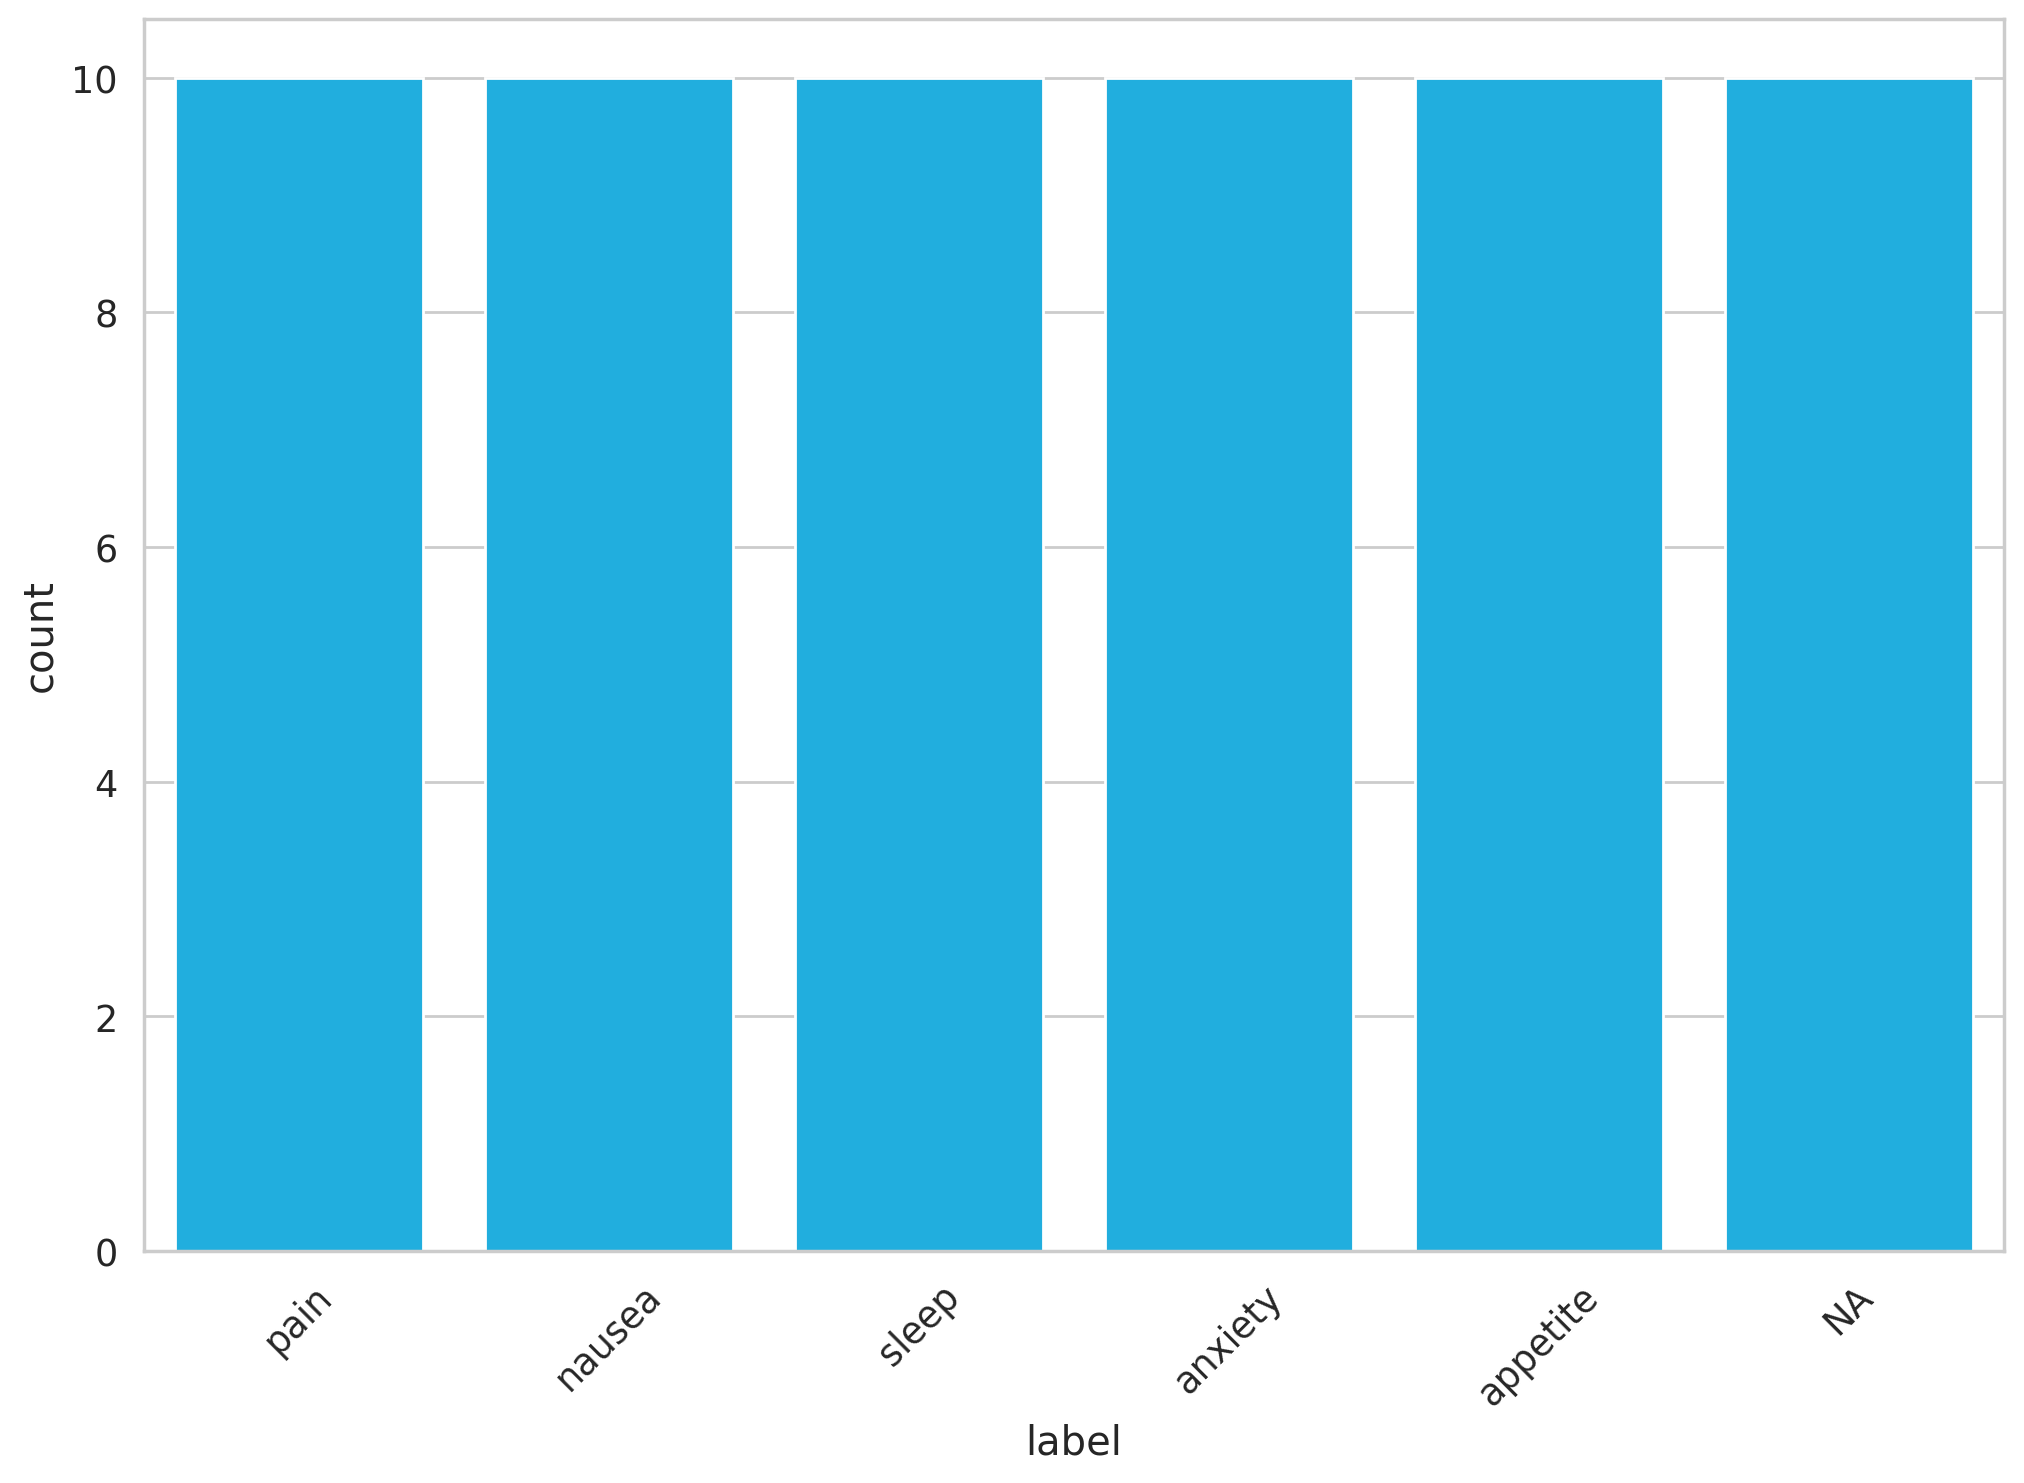

In [3]:
# distribution of the four class in sentiment
sns.barplot(x=df_test.label.value_counts().index, y=df_test.label.value_counts())
plt.xticks(ticks=range(len(class_label_names)), labels=class_label_names, rotation=45)
plt.xlabel('label')

In [4]:
from transformers import AutoTokenizer, AutoModel
# PRE_TRAINED_MODEL_NAME="roberta-large-mnli"
tokenizer = AutoTokenizer.from_pretrained('LLMs/gatortron-base', local_files_only=True)


In [5]:
tokenizer.sep_token, tokenizer.sep_token_id


('[SEP]', 102)

In [6]:
tokenizer.cls_token, tokenizer.cls_token_id


('[CLS]', 101)

In [7]:
tokenizer.pad_token, tokenizer.pad_token_id


('[PAD]', 0)

In [8]:
tokenizer.unk_token, tokenizer.unk_token_id


('[UNK]', 100)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


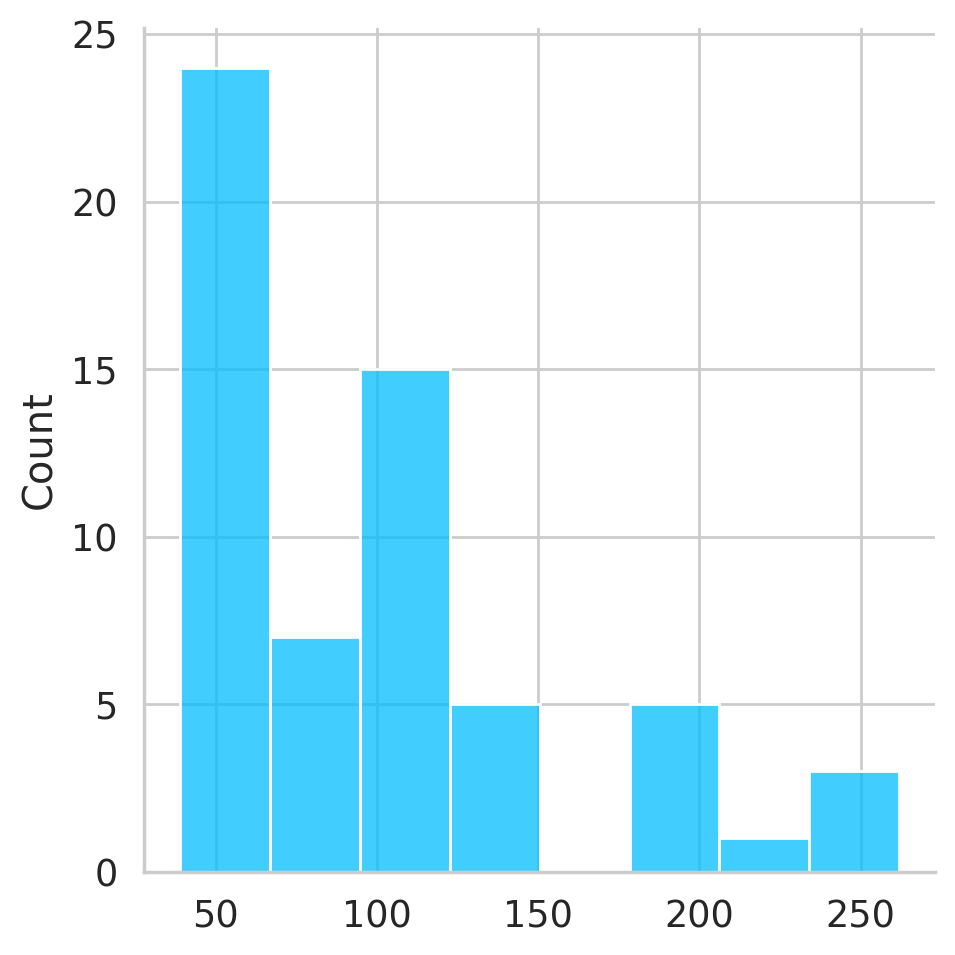

In [9]:
token_lens=[]
for txt in df_test.text:
  tokens=tokenizer.encode(txt,max_length=512)
  token_lens.append(len(tokens))
sns.displot(token_lens)

In [10]:
class CannabisClassData(Dataset):
  def __init__(self, text, label, tokenizer, max_len):
    self.text=text
    self.label=label
    self.tokenizer=tokenizer
    self.max_len=max_len
    
  def __len__(self):
    return len(self.text)
  
  def __getitem__(self,item):
    text= str(self.text[item])
    label=self.label[item]
    encoding=self.tokenizer.encode_plus(
    text,
    max_length=self.max_len,
    add_special_tokens=True,
    # pad_to_max_length=True,
    truncation =True,
    return_attention_mask=True,
    return_token_type_ids=False,
    return_tensors='pt'
    )
    return{
        'text':text,
        'input_ids': encoding['input_ids'].flatten(),
        'attention_mask': encoding['attention_mask'].flatten(),
        'label':torch.tensor(label,dtype=torch.long)
    }

    


In [11]:
from torch.nn.utils.rnn import pad_sequence
def collate_fn(batch):
    input_ids = [b["input_ids"] for b in batch]
    attention_mask = [b["attention_mask"] for b in batch]
    labels = [b["label"] for b in batch]
    

    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)
    labels = torch.tensor(labels)

    return {"input_ids": input_ids, "attention_mask": attention_mask, "label": labels}


def create_data_loader(df, tokenizer, max_len, batch_size, collate_fn=collate_fn):
  ds = CannabisClassData(
    text=df.text.to_numpy(),
    label=df.label.to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
  )
  return DataLoader(
    ds,
    batch_size=batch_size,
    num_workers=0,
    collate_fn=collate_fn
  )
     

In [12]:
class CannabisClassifier(nn.Module):
  def __init__(self,PRE_TRAINED_MODEL_NAME,n_classes, dropout_rate=0.3):
    super(CannabisClassifier,self).__init__()
    self.bert=AutoModel.from_pretrained(PRE_TRAINED_MODEL_NAME, local_files_only=True)
    self.drop=nn.Dropout(p=dropout_rate)
    self.out=nn.Linear(self.bert.config.hidden_size,n_classes)
    self.softmax=nn.Softmax(dim=1)
  def forward(self,input_ids,attention_mask):
    _,pooled_output=self.bert(
      input_ids=input_ids,
      attention_mask=attention_mask,
      return_dict=False
    )
    output=self.drop(pooled_output)
    output=self.out(output)
    #return self.softmax(output)
    return nn.LogSoftmax(dim=1)(output)

In [13]:
class CannabisClassifierFrozenBackbone(nn.Module):
    def __init__(self, PRE_TRAINED_MODEL_NAME, n_classes, dropout_rate=0.1):
        super(CannabisClassifierFrozenBackbone, self).__init__()
        self.bert = AutoModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
        for param in self.bert.parameters():
            param.requires_grad = False
        hidden_size = self.bert.config.hidden_size
        self.drop=nn.Dropout(p=dropout_rate)
        self.out = nn.Linear(hidden_size, n_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, input_ids, attention_mask):
        _, pooled_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=False
        )
        output=self.drop(pooled_output)
        output=self.out(output)
        #return self.softmax(output)
        return nn.LogSoftmax(dim=1)(output)

In [14]:
def train_epoch(
    model,
    data_loader,
    loss_fn,
    optimizer,
    device,
    scheduler,
):
    model=model.train()
    model.to(device)
    losses=[]
    running_loss=0.0

    for d in data_loader:
      input_ids=d['input_ids'].to(device)
      attention_mask=d['attention_mask'].to(device)
      label=d['label'].to(device)


      outputs=model(
          input_ids=input_ids,
          attention_mask=attention_mask
      )

      preds=torch.max(outputs,dim=1)
      loss=loss_fn(outputs,label)

      #correct_predictions += torch.sum(torch.eq(preds, label))
      # correct_predictions +=torch.sum(torch.eq(torch.argmax(outputs,dim=1).cpu(), label.cpu()))
      losses.append(loss.item())

      loss.backward()
      nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
      optimizer.step()
      scheduler.step()
      optimizer.zero_grad()
      running_loss += loss.item() / len(data_loader)

    return running_loss

In [15]:
import torch

def eval_model(model, data_loader, loss_fn, device):
    model.eval()  # set model to evaluation mode
    model.to(device)
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            labels = d["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = loss_fn(outputs, labels)
            total_loss += loss.item()

            # predictions = argmax over class dimension
            preds = torch.argmax(outputs, dim=1)
            correct_predictions += torch.sum(preds == labels).item()
            total_samples += labels.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions / total_samples

    return avg_loss, accuracy


In [16]:
def get_predictions(model, data_loader):
  model = model.eval()
  model.to(device)
  
  predictions = []
  prediction_probs = []
  real_values = []

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      label = d["label"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)

      probs = F.softmax(outputs, dim=1)

      predictions.extend(preds)
      prediction_probs.extend(probs)
      real_values.extend(label)

  predictions = torch.stack(predictions).cpu()
  prediction_probs = torch.stack(prediction_probs).cpu()
  real_values = torch.stack(real_values).cpu()

  return predictions, prediction_probs, real_values

Text(0.5, 0, 'sentiment')

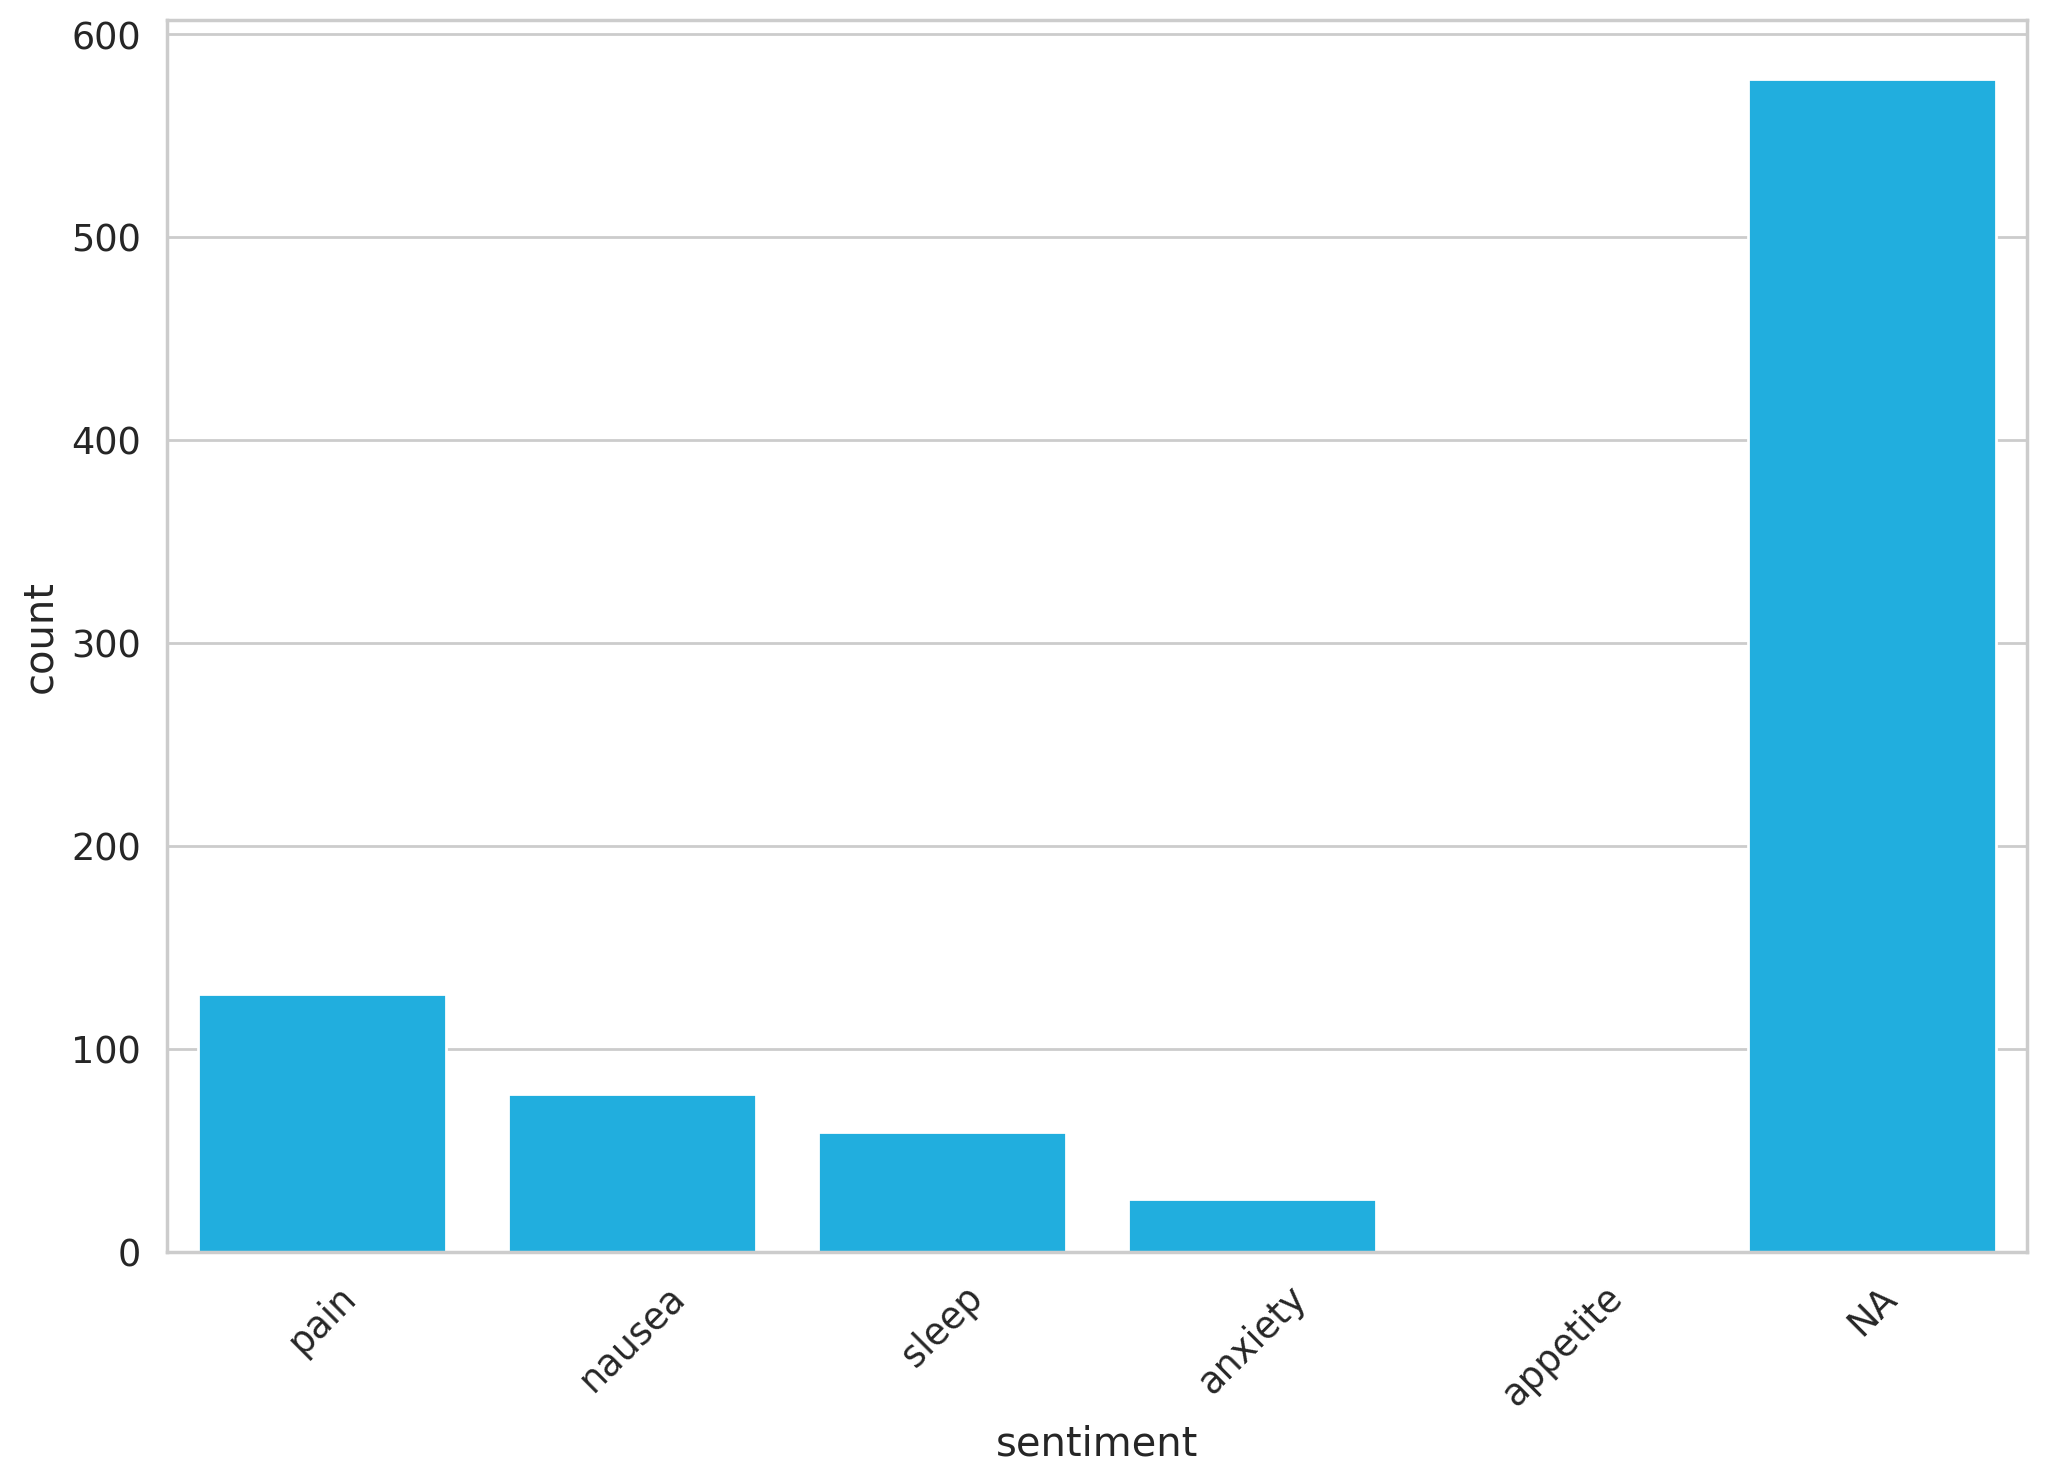

In [17]:

df_train = pd.read_csv("data/set-train_task-reason_label-6_desc-all.csv")
df_train = df_train.rename(columns={"Label": "label"})
df_train['label'] = df_train['label']-1

# distribution of the six class in sentiment
sns.barplot(x=df_train.label.value_counts().index, y=df_train.label.value_counts())
plt.xticks(ticks=range(len(class_label_names)), labels=class_label_names, rotation=45)
plt.xlabel('sentiment')

In [18]:
import optuna
PRE_TRAINED_MODEL_dir='LLMs/gatortron-base'
from transformers import AutoTokenizer, DataCollatorWithPadding
# ——————— Optuna objective ——————————————————————————
def objective(trial: optuna.Trial) -> float:
    dropout = trial.suggest_float("dropout", 0.05, 0.2, step=0.05)
    lr = trial.suggest_float("lr", 5e-5, 1e-3, log=True)
    batch = trial.suggest_categorical("batch", [4, 8])
    tune_mode = trial.suggest_categorical("tune_mode", ["full", 'linear_probe'])  # TO DO : add 'lora' back later
    max_len = trial.suggest_int("max_len", 64, 256, step=32)

    df_train = pd.read_csv("data/set-train_task-reason_label-6_desc-all.csv")
    df_train = df_train[["Snippets", "Label"]]
    df_train = df_train.rename(columns={"Label": "label", "Snippets": "text"})
    df_train['label'] = df_train['label']-1
    
    tokenizer = AutoTokenizer.from_pretrained(PRE_TRAINED_MODEL_dir, local_files_only=True)


    print(
        f"\n🔧  Trial {trial.number:02d} "
        f"dropout={dropout}, lr={lr:.2e}, batch={batch}, tune='{tune_mode}, max_len={max_len}'",
        flush=True,
    )

    if tune_mode == "full":
        model = CannabisClassifier(PRE_TRAINED_MODEL_NAME=PRE_TRAINED_MODEL_dir, 
                                   n_classes=len(np.unique(df_train.label)), 
                                   dropout_rate=dropout)
    elif tune_mode == "linear_probe":
        model = CannabisClassifierFrozenBackbone(PRE_TRAINED_MODEL_NAME=PRE_TRAINED_MODEL_dir,
            n_classes=len(np.unique(df_train.label)),
            dropout_rate=dropout
        )
    else:
        raise ValueError(f"Unknown tune mode: {tune_mode}")
    

    

    # split the data into train and val in a cross validation manner:
    from sklearn.model_selection import StratifiedShuffleSplit, ShuffleSplit

    # because appetite is the least frequent class, we cannot use stratifedKFold, use regular split for now
    regular_split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    # TO DO: 1. add SMOTE or other techniques to handle imbalanced data
    # TO DO: 2. add data augmentation techniques
    # skf = StratifiedShuffleSplit(n_splits=2, test_size=0.2, random_state=42)
    for train_idx, val_idx in regular_split.split(df_train, df_train.label):
        train_df = df_train.iloc[train_idx]
        val_df = df_train.iloc[val_idx]
        # print the size of train and val
        print(f"train size: {len(train_df)}, val size: {len(val_df)}")
        
    tr_loader = create_data_loader(train_df, tokenizer, max_len, batch)
    vl_loader = create_data_loader(val_df, tokenizer, max_len, batch)

    best_val, patience, wait = math.inf, 3, 0
    hist: Dict[str, List[float]] = {
        "tloss": [],
        "vloss": [],
        "tacc": [],
        "vacc": [],
    }
    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    loss_fn=nn.CrossEntropyLoss().to(device)
    max_epochs = 10
    total_steps=len(train_df)*max_epochs
    scheduler=get_linear_schedule_with_warmup(
        opt,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )
    
    for ep in range(1, max_epochs + 1):
        # —— training step ——
        model.train()
        tloss = train_epoch(
                model,
                tr_loader,    
                loss_fn, 
                opt, 
                device, 
                scheduler
            )
        

        # —— AUC on train set ——
        _, tacc = eval_model(
                        model,
                        tr_loader,
                        loss_fn,
                        device
                        )
        

        # —— validation ——
        vloss, vacc = eval_model(
                        model,
                        vl_loader,
                        loss_fn,
                        device
                        )
        
        # —— bookkeeping / logging ——
        hist["tloss"].append(tloss)
        hist["vloss"].append(vloss)
        hist["tacc"].append(tacc)
        hist["vacc"].append(vacc)
        print(
            f"[{trial.number:02d}] Ep {ep:02d}/{max_epochs} "
            f"train‑loss {tloss:.4f} val‑loss {vloss:.4f} "
            f"train‑ACC {tacc:.3f} val‑ACC {vacc:.3f}",
            flush=True,
        )

        trial.report(vloss, ep)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if vloss < best_val:  # early‑stop patience
            best_val, wait, best_state = vloss, 0, model.state_dict()
        else:
            wait += 1
            if wait >= patience:
                break

    # —— save curves for later inspection ——
    tdir = f"output/gatortron-base_finetune_reason/trial_{trial.number}/"
    os.makedirs(tdir, exist_ok=True)
    np.save(tdir + "train_loss.npy", np.array(hist["tloss"]))
    np.save(tdir + "val_loss.npy", np.array(hist["vloss"]))
    np.save(tdir + "train_auc.npy", np.array(hist["tacc"]))
    np.save(tdir + "val_auc.npy", np.array(hist["vacc"]))

    def _plot(a1, a2, lab, fn):
        plt.figure()
        plt.plot(a1, label="train")
        plt.plot(a2, label="val")
        plt.xlabel("epoch")
        plt.ylabel(lab)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(tdir + fn)
        plt.close()

    _plot(hist["tloss"], hist["vloss"], "loss", "loss_over_epochs.png")
    _plot(hist["tacc"], hist["vacc"], "ACC", "acc_over_epochs.png")

    trial.set_user_attr("best_state", best_state)
    return best_val



In [19]:
# use Optuna to optimize hyperparameters


num_trials=10
hparam_func = lambda trial: {
    "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
    "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32]),
    "dropout_rate": trial.suggest_float("dropout_rate", 0.1, 0.5),
    "max_len": trial.suggest_int("max_len", 64, 256, step=32),
    "tune_mode": trial.suggest_categorical("tune_mode", ["full", "linear_probe"]),
}

study = optuna.create_study(
        direction="minimize", sampler=optuna.samplers.TPESampler()
    )
study.optimize(objective, n_trials=num_trials)

best = study.best_trial
params = best.params
print("🔎  Best params:", params)

print('Hparam sweep complete!')
print(f'Best params: {study.best_params}')
print(f'Best loss: {study.best_value:.3f}')




[I 2026-01-23 13:31:09,997] A new study created in memory with name: no-name-188d92c9-c462-41a7-bbf7-50f1fdfa8824



🔧  Trial 00 dropout=0.1, lr=5.03e-05, batch=4, tune='linear_probe, max_len=224'
train size: 695, val size: 174
[00] Ep 01/10 train‑loss 1.1473 val‑loss 1.1767 train‑ACC 0.679 val‑ACC 0.609
[00] Ep 02/10 train‑loss 1.0570 val‑loss 1.1586 train‑ACC 0.679 val‑ACC 0.609
[00] Ep 03/10 train‑loss 1.0457 val‑loss 1.1476 train‑ACC 0.679 val‑ACC 0.609
[00] Ep 04/10 train‑loss 1.0391 val‑loss 1.1390 train‑ACC 0.679 val‑ACC 0.609
[00] Ep 05/10 train‑loss 1.0290 val‑loss 1.1283 train‑ACC 0.679 val‑ACC 0.609
[00] Ep 06/10 train‑loss 1.0198 val‑loss 1.1210 train‑ACC 0.679 val‑ACC 0.609
[00] Ep 07/10 train‑loss 1.0197 val‑loss 1.1140 train‑ACC 0.679 val‑ACC 0.609
[00] Ep 08/10 train‑loss 1.0123 val‑loss 1.1091 train‑ACC 0.679 val‑ACC 0.609
[00] Ep 09/10 train‑loss 1.0051 val‑loss 1.1012 train‑ACC 0.679 val‑ACC 0.609
[00] Ep 10/10 train‑loss 1.0041 val‑loss 1.0955 train‑ACC 0.679 val‑ACC 0.609


[I 2026-01-23 13:32:18,246] Trial 0 finished with value: 1.0954704291441224 and parameters: {'dropout': 0.1, 'lr': 5.027427200617692e-05, 'batch': 4, 'tune_mode': 'linear_probe', 'max_len': 224}. Best is trial 0 with value: 1.0954704291441224.



🔧  Trial 01 dropout=0.15000000000000002, lr=1.16e-04, batch=8, tune='full, max_len=128'
train size: 695, val size: 174
[01] Ep 01/10 train‑loss 1.1257 val‑loss 1.2464 train‑ACC 0.679 val‑ACC 0.609
[01] Ep 02/10 train‑loss 1.0778 val‑loss 1.2318 train‑ACC 0.679 val‑ACC 0.609
[01] Ep 03/10 train‑loss 1.0682 val‑loss 1.0245 train‑ACC 0.636 val‑ACC 0.598
[01] Ep 04/10 train‑loss 0.8175 val‑loss 1.0167 train‑ACC 0.793 val‑ACC 0.701
[01] Ep 05/10 train‑loss 0.5990 val‑loss 1.5743 train‑ACC 0.819 val‑ACC 0.701
[01] Ep 06/10 train‑loss 0.5157 val‑loss 1.1161 train‑ACC 0.871 val‑ACC 0.770
[01] Ep 07/10 train‑loss 0.4243 val‑loss 0.9653 train‑ACC 0.909 val‑ACC 0.787
[01] Ep 08/10 train‑loss 0.3041 val‑loss 0.8199 train‑ACC 0.967 val‑ACC 0.839
[01] Ep 09/10 train‑loss 0.2564 val‑loss 1.0562 train‑ACC 0.968 val‑ACC 0.805
[01] Ep 10/10 train‑loss 0.1440 val‑loss 1.0498 train‑ACC 0.983 val‑ACC 0.845


[I 2026-01-23 13:33:51,153] Trial 1 finished with value: 0.8198950965042141 and parameters: {'dropout': 0.15000000000000002, 'lr': 0.00011575105851007444, 'batch': 8, 'tune_mode': 'full', 'max_len': 128}. Best is trial 1 with value: 0.8198950965042141.


...


🔧  Trial 08 dropout=0.1, lr=5.68e-05, batch=4, tune='full, max_len=64'
train size: 695, val size: 174
[08] Ep 01/10 train‑loss 1.1122 val‑loss 1.1861 train‑ACC 0.679 val‑ACC 0.609


[I 2026-01-23 13:39:48,356] Trial 8 pruned. 



🔧  Trial 09 dropout=0.1, lr=1.58e-04, batch=4, tune='full, max_len=160'
train size: 695, val size: 174
[09] Ep 01/10 train‑loss 1.1323 val‑loss 1.2507 train‑ACC 0.679 val‑ACC 0.609


[I 2026-01-23 13:40:02,804] Trial 9 pruned. 


🔎  Best params: {'dropout': 0.15000000000000002, 'lr': 0.00011575105851007444, 'batch': 8, 'tune_mode': 'full', 'max_len': 128}
Hparam sweep complete!
Best params: {'dropout': 0.15000000000000002, 'lr': 0.00011575105851007444, 'batch': 8, 'tune_mode': 'full', 'max_len': 128}
Best loss: 0.820


In [20]:
# — rebuild best model (train + val) —————————————————
if params.get("tune_mode", "full") == "full":
    model = CannabisClassifier(
        PRE_TRAINED_MODEL_NAME=PRE_TRAINED_MODEL_dir,
        n_classes=len(np.unique(df_test.label)),
        dropout_rate=params["dropout"],
    )
else:
    model = CannabisClassifierFrozenBackbone(
        PRE_TRAINED_MODEL_NAME=PRE_TRAINED_MODEL_dir,
        n_classes=len(np.unique(df_test.label)),
        dropout_rate=params["dropout"],
    )


model.load_state_dict(best.user_attrs["best_state"])
model.eval()
loss_fn=nn.CrossEntropyLoss().to(device)
# — final **test** evaluation ————————————————————
test_loader = create_data_loader(df_test, tokenizer, params['max_len'], 1)
test_loss, test_acc = eval_model(
    model,
    test_loader,
    loss_fn,
    device
)

print(f"\n FINAL TEST — ACC={test_acc:.3f} LOSS={test_loss:.3f}")
# save the final best model
tdir = f"output/gatortron-base_finetune_reason/best_model/"
os.makedirs(tdir, exist_ok=True)
torch.save(model.state_dict(), tdir + f"best_model_state_tune-{params['tune_mode']}.bin")

# save the params
import json
with open(tdir + f"best_model_params.json", 'w') as f:
    json.dump(params, f, indent=4)

# save the final model
torch.save(model.state_dict(), "output/gatortron-base_finetune_reason/FineTunedGatorTron_task-reason_final.pth")



 FINAL TEST — ACC=0.533 LOSS=3.504


In [21]:
y_pred, y_pred_probs, y_test = get_predictions(
  model,
  test_loader
)

In [22]:

print(classification_report(y_test, y_pred, target_names=class_label_names))
    

              precision    recall  f1-score   support

        pain       0.50      0.50      0.50        10
      nausea       0.78      0.70      0.74        10
       sleep       0.80      0.40      0.53        10
     anxiety       0.86      0.60      0.71        10
    appetite       0.00      0.00      0.00        10
          NA       0.34      1.00      0.51        10

    accuracy                           0.53        60
   macro avg       0.55      0.53      0.50        60
weighted avg       0.55      0.53      0.50        60



/home/yiyuw/miniconda3/envs/llm_ard/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/yiyuw/miniconda3/envs/llm_ard/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/yiyuw/miniconda3/envs/llm_ard/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [ ]:
#  make confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=class_label_names, columns=class_label_names)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()